# P1 · ROI Analysis: SNAP Legacy vs Daedalus Resource Utilization

This notebook visualizes the resource utilization comparison between the legacy SNAP workflow and the new Daedalus orchestrator.

**Data sources:**
- Legacy: LSF Job Done PDFs (upstream + integrative)
- Daedalus: resource_usage JSON from Sprocket run

In [27]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded.")

Libraries loaded.


In [28]:
INPUT_DIR_PATH = ROOT_DIR / 'input'
DOCS_DIR_PATH = ROOT_DIR / 'docs'
OUTPUT_DIR_PATH = ROOT_DIR / 'output'

LEGACY_UPSTREAM_PDF = INPUT_DIR_PATH / "Job-run-upstream-analysis-Done.pdf"
LEGACY_INTEGRATIVE_PDF = INPUT_DIR_PATH / "Job-run-integrative-analysis-Done.pdf"
DAEDALUS_JSON = INPUT_DIR_PATH / "resource_usage_2026-09-12_143900834470824.json"

ROI_CSV = DOCS_DIR_PATH / 'roi_scenarios.csv'

# Colorblind-safe palette (IBM Design System)
CB_LEGACY   = '#DC267F'   # Magenta
CB_DAEDALUS = '#648FFF'   # Blue
CB_REQUEST  = '#785EF0'   # Indigo / Purple
CB_USED     = '#FE6100'   # Orange

def _polish(ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)

    # Ensure all 4 borders (top, bottom, left, right) are visible
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.0)
        spine.set_visible(True)

    # Turn off all grid lines
    ax.grid(False)

    # Apply legend styling
    ax.legend(framealpha=0.9, fontsize=10)

## 1. Legacy Flow Analysis

Parse LSF Job Done PDFs and calculate resource utilization.

In [29]:
from scripts.roi_calculator import parse_job_output, calculate_utilization, read_input_file

# Parse legacy data
legacy_up_text = read_input_file(Path(LEGACY_UPSTREAM_PDF))
legacy_int_text = read_input_file(Path(LEGACY_INTEGRATIVE_PDF))

legacy_up_metrics = parse_job_output(legacy_up_text)
legacy_int_metrics = parse_job_output(legacy_int_text)

legacy_up_results = calculate_utilization(legacy_up_metrics)
legacy_int_results = calculate_utilization(legacy_int_metrics)

In [30]:
# Build legacy dataframe
legacy_data = []
for name, metrics, results in [
    ("Upstream", legacy_up_metrics, legacy_up_results),
    ("Integrative", legacy_int_metrics, legacy_int_results)
]:
    legacy_data.append({
        "Module": name,
        "Job ID": metrics.get('job_name', 'N/A'),
        "Cores": metrics.get('cores', 0),
        "Per-Slot Mem Req (GB)": metrics.get('rusage_mem_gb', 0),
        "Wall-clock (h)": round(metrics.get('run_time_sec', 0) / 3600, 2),
        "CPU Time (s)": metrics.get('cpu_time_sec', 0),
        "Allocated Core-time (s)": results.get('allocated_core_time_sec', metrics.get('run_time_sec', 0) * metrics.get('cores', 0)),
        "Total Requested Mem (GB)": round(metrics.get('total_requested_memory_mb', 0) / 1024, 1),
        "Avg Memory (GB)": round(metrics.get('avg_memory_mb', 0) / 1024, 1),
        "Max Memory (GB)": round(metrics.get('max_memory_mb', 0) / 1024, 1),
        "Memory Util (%)": round(results.get('memory_utilization_pct', 0), 1),
        "CPU Util (%)": round(results.get('cpu_utilization_pct', 0), 1),
        "Memory Waste (GB)": round(results.get('memory_waste_gb', 0), 1),
        "CPU Waste (%)": round(100 - results.get('cpu_utilization_pct', 0), 1),
    })

df_legacy = pd.DataFrame(legacy_data).set_index("Module")
df_legacy

,Job ID,Cores,Per-Slot Mem Req (GB),Wall-clock (h),CPU Time (s),Allocated Core-time (s),Total Requested Mem (GB),Avg Memory (GB),Max Memory (GB),Memory Util (%),CPU Util (%),Memory Waste (GB),CPU Waste (%)
Module,,,,,,,,,,,,,
Upstream,run-upstream-analysis,16,30,1.79,7304.0,103120.0,480.0,46.0,96.2,9.6,7.1,434.0,92.9
Integrative,run-integrative-analysis,10,96,0.27,642.0,9540.0,960.0,14.1,23.8,1.5,6.7,945.9,93.3


## 2. Daedalus Flow Analysis

Parse Sprocket resource_usage JSON and calculate utilization.

In [31]:
from scripts.roi_calculator_daedalus import parse_modules, calculate_utilization as calc_util_daedalus

# Read Daedalus JSON
import json
with open(DAEDALUS_JSON, 'r') as f:
    daedalus_data = json.load(f)

# Parse modules
daedalus_modules = parse_modules(daedalus_data)

# Build Daedalus dataframe
daedalus_data_list = []
daedalus_results = {}
for mod in daedalus_modules:
    results = calc_util_daedalus(mod)
    daedalus_results[mod['module']] = (mod, results)
    daedalus_data_list.append({
        "Module": mod['module'].title(),
        "Cores": mod.get('requested_cpu', 0),
        "Per-Slot Mem Requested (GB)": mod.get('requested_memory_gb', 0),
        "Wall-clock (h)": round(mod.get('wall_time_sec', 0) / 3600, 2),
        "CPU Time (s)": mod.get('cpu_time_sec', 0),
        "Allocated Core-time (s)": round(mod.get('wall_time_sec', 0) * mod.get('requested_cpu', 0), 1),
        "Total Requested Mem (GB)": round(metrics.get('total_requested_memory_gb', 0), 1),
        "Avg Memory (GB)": round(mod.get('actual_avg_memory_gb', 0), 1),
        "Max Memory (GB)": round(mod.get('actual_max_memory_gb', 0), 1),
        "Memory Util (%)": round(results.get('memory_utilization_pct', 0), 1),
        "CPU Util (%)": round(results.get('cpu_utilization_pct', 0), 1),
        "Memory Waste (GB)": round(results.get('memory_waste_gb', 0), 1),
        "CPU Waste (%)": round(100 - results.get('cpu_utilization_pct', 0), 1),
    })

df_daedalus = pd.DataFrame(daedalus_data_list).set_index("Module")
df_daedalus

,Cores,Per-Slot Mem Requested (GB),Wall-clock (h),CPU Time (s),Allocated Core-time (s),Total Requested Mem (GB),Avg Memory (GB),Max Memory (GB),Memory Util (%),CPU Util (%),Memory Waste (GB),CPU Waste (%)
Module,,,,,,,,,,,,
Integrative,10,116.0,0.29,612.8,10480.0,0,6.3,10.3,0.5,5.8,-1044.0,94.2
Upstream,8,36.0,1.14,3768.4,32696.0,0,8.5,21.7,3.0,11.5,-252.0,88.5


## 3. Side-by-Side Comparison

Combine legacy and Daedalus data into a single comparison table.

In [32]:
# Build comparison dataframe
comparison_data = []

# Legacy data
for name, metrics, results in [
    ("Upstream (Legacy)", legacy_up_metrics, legacy_up_results),
    ("Integrative (Legacy)", legacy_int_metrics, legacy_int_results)
]:
    comparison_data.append({
        "Module": name,
        "Wall-clock (h)": metrics.get('run_time_sec', 0) / 3600,
        "Cores": metrics.get('cores', 0),
        "CPU Time (s)": metrics.get('cpu_time_sec', 0),
        "Avg Memory (GB)": metrics.get('avg_memory_mb', 0) / 1024,
        "Max Memory (GB)": metrics.get('max_memory_mb', 0) / 1024,
        "Per-Slot Requested Memory (GB)": metrics.get('rusage_mem_gb', 0),
        "Total Requested Mem (GB)": round(metrics.get('total_requested_memory_mb', 0) / 1024, 1),
        "Memory Util (%)": results.get('memory_utilization_pct', 0),
        "CPU Util (%)": results.get('cpu_utilization_pct', 0),
    })

# Daedalus data
for mod_name, (mod, results) in daedalus_results.items():
    comparison_data.append({
        "Module": f"{mod_name.title()} (Daedalus)",
        "Wall-clock (h)": mod.get('wall_time_sec', 0) / 3600,
        "Cores": mod.get('requested_cpu', 0),
        "CPU Time (s)": mod.get('cpu_time_sec', 0),
        "Avg Memory (GB)": mod.get('actual_avg_memory_gb', 0),
        "Max Memory (GB)": mod.get('actual_max_memory_gb', 0),
        "Per-Slot Requested Memory (GB)": mod.get('requested_memory_gb', 0),
        "Total Requested Mem (GB)": round(mod.get('requested_memory_gb', 0) * mod.get('requested_cpu', 0), 1),
        "Memory Util (%)": results.get('memory_utilization_pct', 0),
        "CPU Util (%)": results.get('cpu_utilization_pct', 0),
    })

df = pd.DataFrame(comparison_data)
df = df.set_index("Module")

print("# Resource Utilization Comparison")
print()
df

# Resource Utilization Comparison



,Wall-clock (h),Cores,CPU Time (s),Avg Memory (GB),Max Memory (GB),Per-Slot Requested Memory (GB),Total Requested Mem (GB),Memory Util (%),CPU Util (%)
Module,,,,,,,,,
Upstream (Legacy),1.790278,16,7304.0,46.013291,96.213867,30.0,480.0,9.586102,7.083010
Integrative (Legacy),0.265000,10,642.0,14.095596,23.843750,96.0,960.0,1.468291,6.729560
Integrative (Daedalus),0.291111,10,612.8,6.300000,10.300000,116.0,1160.0,0.543103,5.847328
Upstream (Daedalus),1.135278,8,3768.4,8.500000,21.700000,36.0,288.0,2.951389,11.525569


## 4. Analyst ROI Scenarios

In [33]:
import csv

scenarios = []
with open(ROI_CSV, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        scenarios.append({
            'Scenario': row['scenario'].title(),
            'Analyst Hrs (Legacy)': float(row['legacy_analyst_hours_per_run']),
            'Analyst Hrs (Daedalus)': float(row['daedalus_analyst_hours_per_run']),
            'Runs/Year': int(row['runs_per_year']),
            'Analyst Savings/Run': f"${float(row['analyst_savings_per_run_usd']):.2f}",
            'HPC Savings/Run': f"${float(row['hpc_savings_per_run_usd']):.2f}",
            'Annual Savings': f"${float(row['annual_savings_usd']):,.0f}",
            'Net Benefit': f"${float(row['net_annual_benefit_usd']):,.0f}",
            'ROI': f"{float(row['roi_pct']):.1f}%",
            'Payback (runs)': f"{float(row['payback_runs']):.1f}",
        })

df_scenarios = pd.DataFrame(scenarios).set_index('Scenario')
df_scenarios

,Analyst Hrs (Legacy),Analyst Hrs (Daedalus),Runs/Year,Analyst Savings/Run,HPC Savings/Run,Annual Savings,Net Benefit,ROI,Payback (runs)
Scenario,,,,,,,,,
Low,4.0,1.0,12,$144.24,$1.43,"$1,748","$1,348",-32.6%,13.7
Expected,6.0,1.5,24,$216.36,$2.14,"$5,244","$4,620",48.1%,14.3
High,8.0,2.0,48,$288.48,$3.04,"$13,993","$12,653",136.1%,18.4


## 4. Visualizations

### 4.1 Memory Utilization

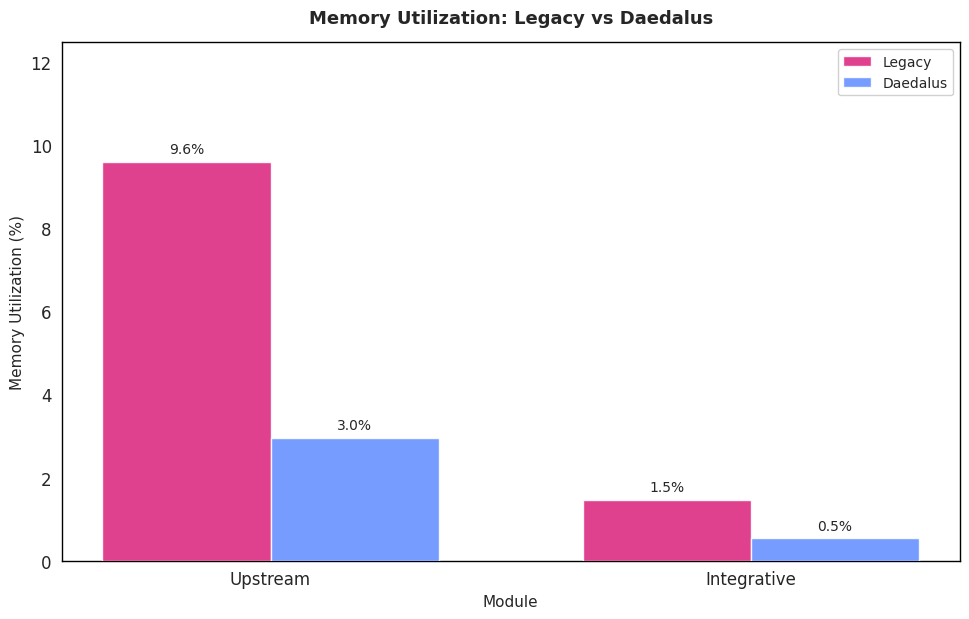

Saved: memory_utilization_comparison.png


In [34]:
fig, ax = plt.subplots(figsize=(10, 6.5))

modules = ["Upstream", "Integrative"]
legacy_mem_util = [
    legacy_up_results.get('memory_utilization_pct', 0),
    legacy_int_results.get('memory_utilization_pct', 0)
]

daedalus_mem_util = []
for mod_name in ['upstream', 'integrative']:
    if mod_name in daedalus_results:
        _, res = daedalus_results[mod_name]
        daedalus_mem_util.append(res.get('memory_utilization_pct', 0))
    else:
        daedalus_mem_util.append(0)

x = range(len(modules))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], legacy_mem_util,   width, label='Legacy',   color=CB_LEGACY,   alpha=0.88, zorder=3)
bars2 = ax.bar([i + width/2 for i in x], daedalus_mem_util, width, label='Daedalus', color=CB_DAEDALUS, alpha=0.88, zorder=3)

ax.set_xlabel('Module', fontsize=11)
ax.set_ylabel('Memory Utilization (%)', fontsize=11)
_polish(ax, 'Memory Utilization: Legacy vs Daedalus')
ax.set_xticks(list(x))
ax.set_xticklabels(modules)
ax.set_ylim(0, max(max(legacy_mem_util), max(daedalus_mem_util)) * 1.30)

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(OUTPUT_DIR_PATH / 'memory_utilization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: memory_utilization_comparison.png")


### 4.2 CPU Utilization

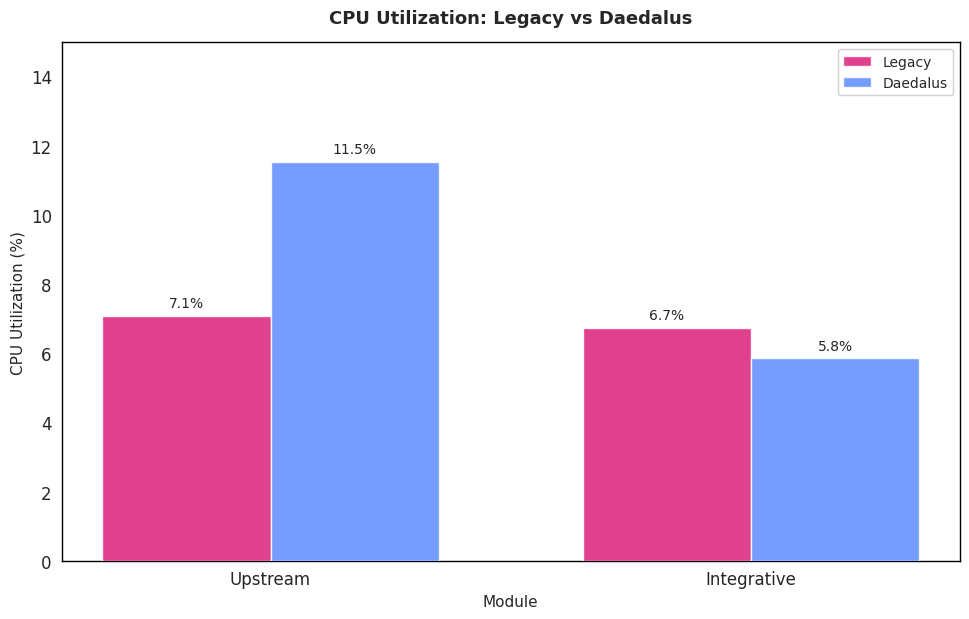

Saved: cpu_utilization_comparison.png


In [35]:
fig, ax = plt.subplots(figsize=(10, 6.5))

legacy_cpu_util = [
    legacy_up_results.get('cpu_utilization_pct', 0),
    legacy_int_results.get('cpu_utilization_pct', 0)
]

daedalus_cpu_util = []
for mod_name in ['upstream', 'integrative']:
    if mod_name in daedalus_results:
        _, res = daedalus_results[mod_name]
        daedalus_cpu_util.append(res.get('cpu_utilization_pct', 0))
    else:
        daedalus_cpu_util.append(0)

x = range(len(modules))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], legacy_cpu_util,   width, label='Legacy',   color=CB_LEGACY,   alpha=0.88, zorder=3)
bars2 = ax.bar([i + width/2 for i in x], daedalus_cpu_util, width, label='Daedalus', color=CB_DAEDALUS, alpha=0.88, zorder=3)

ax.set_xlabel('Module', fontsize=11)
ax.set_ylabel('CPU Utilization (%)', fontsize=11)
_polish(ax, 'CPU Utilization: Legacy vs Daedalus')
ax.set_xticks(list(x))
ax.set_xticklabels(modules)
ax.set_ylim(0, max(max(legacy_cpu_util), max(daedalus_cpu_util)) * 1.30)

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(OUTPUT_DIR_PATH / 'cpu_utilization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cpu_utilization_comparison.png")


### 4.3 Memory Usage (Avg vs Requested)

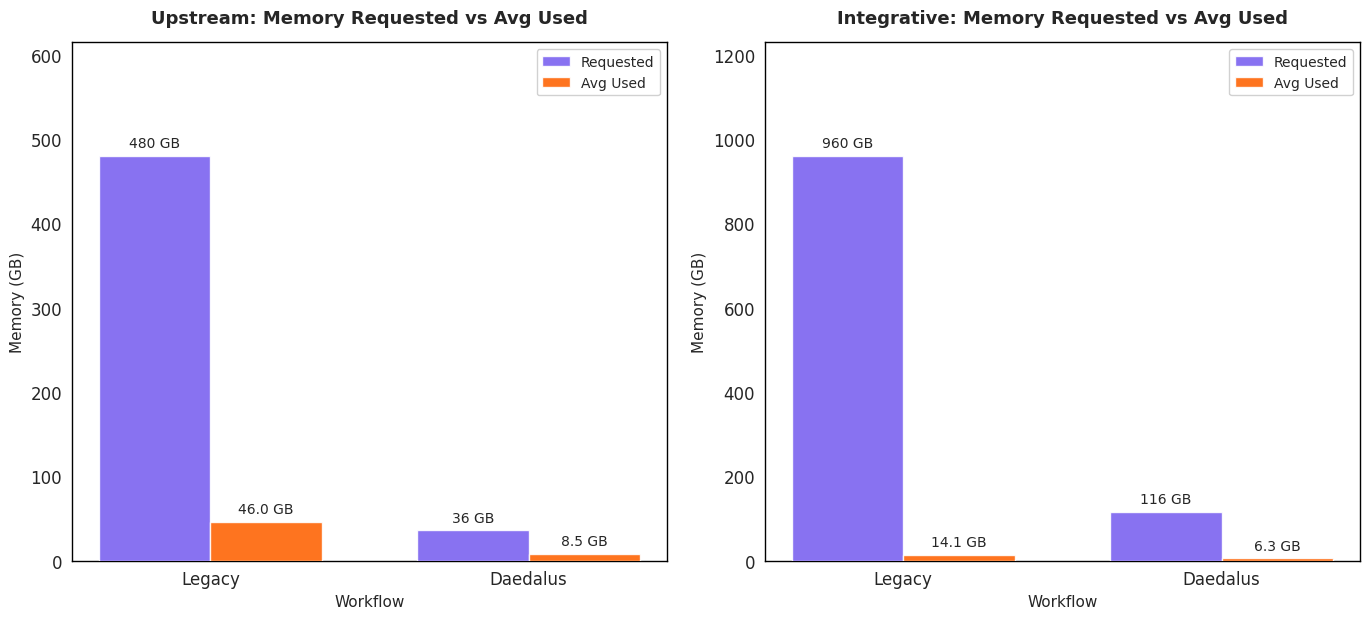

Saved: memory_requested_vs_used.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

labels = ['Legacy', 'Daedalus']
x = range(len(labels))
width = 0.35

for ax, mod_name, title_mod, legacy_metrics, daed_key in [
    (axes[0], 'upstream',     'Upstream',     legacy_up_metrics,  'upstream'),
    (axes[1], 'integrative',  'Integrative',  legacy_int_metrics, 'integrative'),
]:
    avg_mem = [legacy_metrics.get('avg_memory_mb', 0)/1024,
               daedalus_results[daed_key][0].get('actual_avg_memory_gb', 0)]
    req_mem = [legacy_metrics.get('total_requested_memory_mb', 0)/1024,
               daedalus_results[daed_key][0].get('requested_memory_gb', 0)]

    bars1 = ax.bar([i - width/2 for i in x], req_mem, width, label='Requested', color=CB_REQUEST, alpha=0.88, zorder=3)
    bars2 = ax.bar([i + width/2 for i in x], avg_mem, width, label='Avg Used',  color=CB_USED,    alpha=0.88, zorder=3)

    ax.set_xlabel('Workflow', fontsize=11)
    ax.set_ylabel('Memory (GB)', fontsize=11)
    _polish(ax, f'{title_mod}: Memory Requested vs Avg Used')
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max(req_mem) * 1.28)

    for bar in bars1:
        h = bar.get_height()
        ax.annotate(f'{h:.0f} GB', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10)
    for bar in bars2:
        h = bar.get_height()
        ax.annotate(f'{h:.1f} GB', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(OUTPUT_DIR_PATH / 'memory_requested_vs_used.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: memory_requested_vs_used.png")


### 4.4 Analyst Time & Cost Savings by Scenario

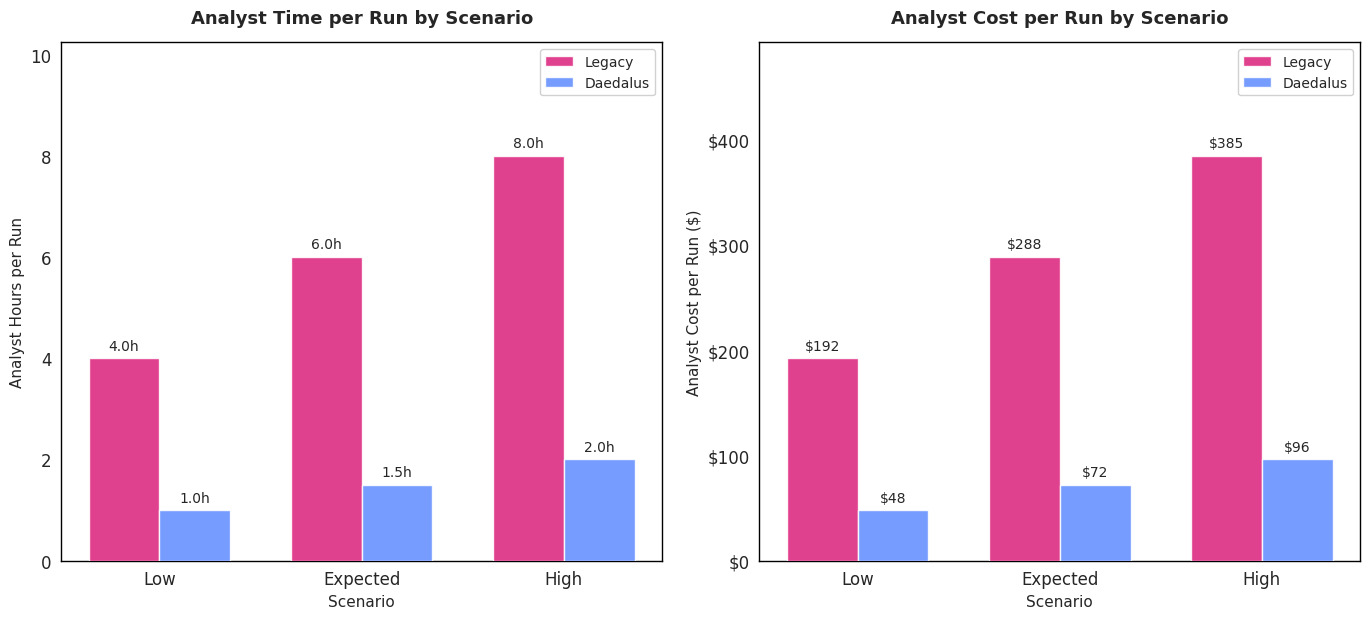

Saved: output/analyst_savings_by_scenario.png


In [37]:
scenarios_df = pd.read_csv(ROI_CSV)

scenarios_df['legacy_analyst_cost']   = scenarios_df['legacy_analyst_hours_per_run']   * scenarios_df['analyst_hourly_rate_usd']
scenarios_df['daedalus_analyst_cost'] = scenarios_df['daedalus_analyst_hours_per_run'] * scenarios_df['analyst_hourly_rate_usd']

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
x = range(len(scenarios_df))
width = 0.35
scenario_labels = scenarios_df['scenario'].str.title()

# Plot 1: Analyst hours per run
ax = axes[0]
bars1 = ax.bar([i - width/2 for i in x], scenarios_df['legacy_analyst_hours_per_run'],   width, label='Legacy',   color=CB_LEGACY,   alpha=0.88, zorder=3)
bars2 = ax.bar([i + width/2 for i in x], scenarios_df['daedalus_analyst_hours_per_run'], width, label='Daedalus', color=CB_DAEDALUS, alpha=0.88, zorder=3)
ax.set_xlabel('Scenario', fontsize=11)
ax.set_ylabel('Analyst Hours per Run', fontsize=11)
_polish(ax, 'Analyst Time per Run by Scenario')
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_labels)
ax.set_ylim(0, scenarios_df['legacy_analyst_hours_per_run'].max() * 1.28)
for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}h', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}h', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)

# Plot 2: Analyst cost per run
ax = axes[1]
bars1 = ax.bar([i - width/2 for i in x], scenarios_df['legacy_analyst_cost'],   width, label='Legacy',   color=CB_LEGACY,   alpha=0.88, zorder=3)
bars2 = ax.bar([i + width/2 for i in x], scenarios_df['daedalus_analyst_cost'], width, label='Daedalus', color=CB_DAEDALUS, alpha=0.88, zorder=3)
ax.set_xlabel('Scenario', fontsize=11)
ax.set_ylabel('Analyst Cost per Run ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
_polish(ax, 'Analyst Cost per Run by Scenario')
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_labels)
ax.set_ylim(0, scenarios_df['legacy_analyst_cost'].max() * 1.28)
for bar in bars1:
    ax.annotate(f'${bar.get_height():,.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.annotate(f'${bar.get_height():,.0f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(OUTPUT_DIR_PATH / 'analyst_savings_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/analyst_savings_by_scenario.png')


### 4.5 HPC Savings by Scenario

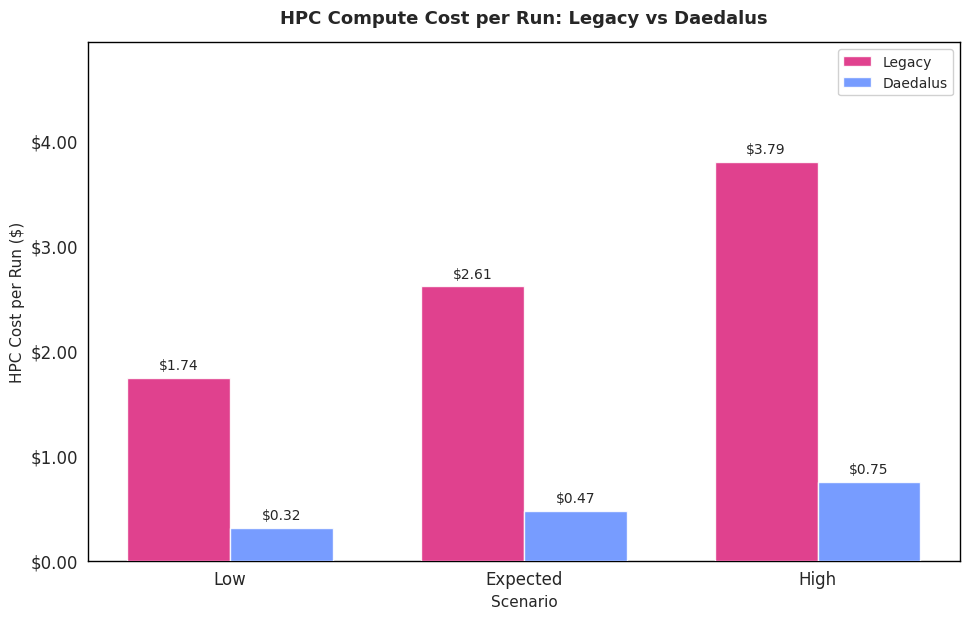

Saved: output/hpc_cost_comparison.png


In [38]:
legacy_cpu_hours    = (16 * 1.79) + (10 * 0.265)
legacy_mem_gb_hours = (480 * 1.79) + (960 * 0.265)
daedalus_cpu_hours    = (8 * 1.14) + (10 * 0.29)
daedalus_mem_gb_hours = (36 * 1.14) + (116 * 0.29)

legacy_hpc_costs   = (legacy_cpu_hours * scenarios_df['hpc_cpu_hour_rate_usd']) + (legacy_mem_gb_hours * scenarios_df['hpc_memory_gb_hour_rate_usd'])
daedalus_hpc_costs = (daedalus_cpu_hours * scenarios_df['hpc_cpu_hour_rate_usd']) + (daedalus_mem_gb_hours * scenarios_df['hpc_memory_gb_hour_rate_usd'])

fig, ax = plt.subplots(figsize=(10, 6.5))
x = range(len(scenarios_df))
width = 0.35
scenario_labels = scenarios_df['scenario'].str.title()

bars1 = ax.bar([i - width/2 for i in x], legacy_hpc_costs.tolist(),   width, label='Legacy',   color=CB_LEGACY,   alpha=0.88, zorder=3)
bars2 = ax.bar([i + width/2 for i in x], daedalus_hpc_costs.tolist(), width, label='Daedalus', color=CB_DAEDALUS, alpha=0.88, zorder=3)

ax.set_xlabel('Scenario', fontsize=11)
ax.set_ylabel('HPC Cost per Run ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.2f}'))
_polish(ax, 'HPC Compute Cost per Run: Legacy vs Daedalus')
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_labels)
ax.set_ylim(0, max(legacy_hpc_costs.max(), daedalus_hpc_costs.max()) * 1.30)

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'${h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'${h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(OUTPUT_DIR_PATH / 'hpc_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/hpc_cost_comparison.png')


### 4.6 Percentage Comparison: Legacy vs Daedalus

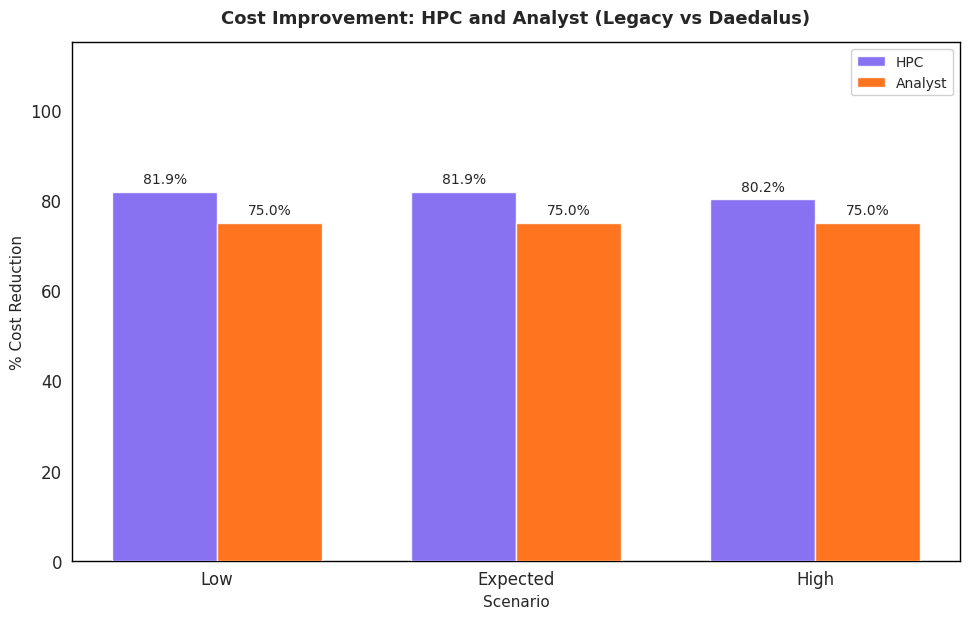

Saved: output/cost_improvement_pct.png


In [39]:
scenarios_df['legacy_analyst_cost']   = scenarios_df['legacy_analyst_hours_per_run']   * scenarios_df['analyst_hourly_rate_usd']
scenarios_df['daedalus_analyst_cost'] = scenarios_df['daedalus_analyst_hours_per_run'] * scenarios_df['analyst_hourly_rate_usd']
scenarios_df['analyst_pct_improvement'] = ((scenarios_df['legacy_analyst_cost'] - scenarios_df['daedalus_analyst_cost']) / scenarios_df['legacy_analyst_cost']) * 100

legacy_cpu_hours    = (16 * 1.79) + (10 * 0.265)
legacy_mem_gb_hours = (480 * 1.79) + (960 * 0.265)
daedalus_cpu_hours    = (8 * 1.14) + (10 * 0.29)
daedalus_mem_gb_hours = (36 * 1.14) + (116 * 0.29)

scenarios_df['legacy_hpc_cost']   = (legacy_cpu_hours * scenarios_df['hpc_cpu_hour_rate_usd']) + (legacy_mem_gb_hours * scenarios_df['hpc_memory_gb_hour_rate_usd'])
scenarios_df['daedalus_hpc_cost'] = (daedalus_cpu_hours * scenarios_df['hpc_cpu_hour_rate_usd']) + (daedalus_mem_gb_hours * scenarios_df['hpc_memory_gb_hour_rate_usd'])
scenarios_df['hpc_pct_improvement'] = ((scenarios_df['legacy_hpc_cost'] - scenarios_df['daedalus_hpc_cost']) / scenarios_df['legacy_hpc_cost']) * 100

x = range(len(scenarios_df))
width = 0.35
scenario_labels = scenarios_df['scenario'].str.title()

fig, ax = plt.subplots(figsize=(10, 6.5))

bars1 = ax.bar([i - width/2 for i in x], scenarios_df['hpc_pct_improvement'],     width, label='HPC',     color=CB_REQUEST, alpha=0.88, zorder=3)
bars2 = ax.bar([i + width/2 for i in x], scenarios_df['analyst_pct_improvement'], width, label='Analyst', color=CB_USED,    alpha=0.88, zorder=3)

ax.set_xlabel('Scenario', fontsize=11)
ax.set_ylabel('% Cost Reduction', fontsize=11)
_polish(ax, 'Cost Improvement: HPC and Analyst (Legacy vs Daedalus)')
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_labels)
ax.set_ylim(0, 115)

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=1.5)
plt.savefig(OUTPUT_DIR_PATH / 'cost_improvement_pct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/cost_improvement_pct.png')


## 5. Summary

### Resource Utilization

1. **Memory utilization worsens but remains low** — 3% and 0.5% as compared to 9.6% and 1.5% for legacy flow.
2. **CPU utilization improved modestly** — Legacy 6.7-7.1% → Daedalus 5.8-11.5%
3. **Peak memory usage dropped significantly** — Upstream: 96→22 GB (77% reduction), Integrative: 24→10 GB (58% reduction)
4. **Wall-clock improved** — Upstream: 1h47m → 1h8m (37% faster) with half the cores (16→8)
5. **Requested resources still much higher than needed** — Even accounting for headroom (20%), the estimator requests 36 GB when avg use is 8.5 GB (4x over-provision)

### Analyst ROI (from scenarios)

Analyst time savings dominate the ROI:
- **Low scenario**: 12 runs/yr, -32.6% ROI (doesn't pay back)
- **Expected scenario**: 24 runs/yr, 48.1% ROI, 14-run payback
- **High scenario**: 48 runs/yr, 136.1% ROI, 18-run payback

**Analyst savings are 99% of total** — HPC compute is negligible at St. Jude pricing ($0.02/core-hr).